# BC01 — Infrastructure de données (notebook de démonstration)

**Objectif :** aller chercher des données réelles dans le monde extérieur, les stocker, les nettoyer
et les transformer en un jeu de données exploitable par le Machine Learning.

Ce notebook **utilise le vrai code** du bloc (`acquisition.py`, `nettoyage.py`) et affiche le
résultat de chaque étape. Il ne réécrit rien : c'est le même code que `run.py`, déroulé cellule par
cellule pour qu'on voie ce qui se passe.

Deux étapes :
1. **Acquisition** — télécharger les observations d'oiseaux (API **GBIF**) et la météo (API
   **Open-Meteo**) → `donnees/brutes/*.csv`
2. **Nettoyage / ETL** — valider, dédupliquer, puis construire une **grille hebdomadaire
   présence/absence** → `donnees/traitees/*.parquet`

## 0. Préparation : rendre le code du projet importable

In [1]:
import sys
from pathlib import Path

# Remonte jusqu'au dossier qui contient le package commun/ (racine du projet)
_racine = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "commun").is_dir())
sys.path.insert(0, str(_racine))

import pandas as pd
import matplotlib.pyplot as plt

from commun.config import (
    ESPECES,
    ZONE_GEOGRAPHIQUE,
    REPERTOIRE_DONNEES_BRUTES,
    REPERTOIRE_DONNEES_TRAITEES,
)
from acquisition import AcquisiteurGBIF, AcquisiteurMeteo, executer_acquisition
from nettoyage import NettoyeurObservations, AggregeurTemporel, traiter_meteo, executer_nettoyage

# Logs moins verbeux : on garde INFO, on masque les DEBUG de pagination
from loguru import logger
logger.remove()
logger.add(sys.stderr, level="INFO")

print("Racine du projet :", _racine)

Racine du projet : C:\Users\Administrateur\Documents\projet_rncp\oiseaux_migrateurs_npdc


## 1. Ce qu'on va chercher

La **zone géographique** (Nord-Pas-de-Calais) et les **4 espèces** migratrices étudiées, avec leur
identifiant GBIF et leur mois d'arrivée attendu.

In [2]:
print(ZONE_GEOGRAPHIQUE)
pd.DataFrame(ESPECES).T[["nom_francais", "nom_scientifique", "code_gbif", "mois_arrivee", "mois_depart"]]

BoundingBoxNPdC(latitude_min=49.5, latitude_max=51.5, longitude_min=1.5, longitude_max=4.0, centre_latitude=50.5, centre_longitude=2.75, nom_region='Nord-Pas-de-Calais')


,nom_francais,nom_scientifique,code_gbif,mois_arrivee,mois_depart
hirondelle_rustique,Hirondelle rustique,Hirundo rustica,9515886,"[4, 5]","[9, 10]"
cigogne_blanche,Cigogne blanche,Ciconia ciconia,2481912,"[3, 4]","[8, 9]"
martinet_noir,Martinet noir,Apus apus,5228676,"[5, 6]","[8, 9]"
bergeronnette_printaniere,Bergeronnette printaniere,Motacilla alba,9687165,"[3, 4]","[10, 11]"


## 2. Acquisition — étape par étape

### 2a. Une seule espèce, pour voir la réponse de l'API GBIF

`AcquisiteurGBIF.telecharger_observations_espece` pagine l'API GBIF (300 résultats par appel),
filtre sur la zone via une géométrie WKT, et réessaie en cas d'erreur passagère (503).

In [3]:
gbif = AcquisiteurGBIF()
df_hirondelle = gbif.telecharger_observations_espece(
    "hirondelle_rustique", ESPECES["hirondelle_rustique"]
)
print("Colonnes :", list(df_hirondelle.columns))
print("Nombre d'observations :", len(df_hirondelle))
df_hirondelle.head()

2026-09-01 17:24:41.777 | INFO     | acquisition:telecharger_observations_espece:72 - Telechargement Hirondelle rustique...


2026-09-01 17:25:28.882 | INFO     | acquisition:telecharger_observations_espece:106 -   10000 observations telechargees pour Hirondelle rustique


Colonnes : ['espece', 'nom_scientifique', 'date_observation', 'latitude', 'longitude', 'precision_coordinate', 'pays', 'source', 'id_gbif']
Nombre d'observations : 10000


,espece,nom_scientifique,date_observation,latitude,longitude,precision_coordinate,pays,source,id_gbif
0,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.400000,3.90000,5000.0,Netherlands,GBIF,4881884490
1,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-02,51.400000,3.90000,5000.0,Netherlands,GBIF,4885294867
2,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-05,51.400000,3.90000,5000.0,Netherlands,GBIF,4885677627
3,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.400000,3.90000,5000.0,Netherlands,GBIF,4887159864
4,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-03-29T17:00,50.509927,2.59639,7.0,France,GBIF,4606830326


### 2b. L'acquisition complète (les 4 espèces + la météo)

`executer_acquisition()` télécharge tout et écrit les CSV bruts. Si les fichiers existent déjà,
l'étape est sautée (passer `forcer=True` pour re-télécharger).

In [4]:
executer_acquisition(forcer=False)

df_brut = pd.read_csv(REPERTOIRE_DONNEES_BRUTES / "observations_gbif.csv")
df_meteo_brut = pd.read_csv(REPERTOIRE_DONNEES_BRUTES / "meteo_npdc.csv")
print(f"observations_gbif.csv : {len(df_brut):>7} lignes")
print(f"meteo_npdc.csv        : {len(df_meteo_brut):>7} lignes")
df_brut.head()

2026-09-01 17:25:28.918 | INFO     | acquisition:executer_acquisition:182 - Donnees brutes deja presentes sur disque -> telechargement saute.


2026-09-01 17:25:28.918 | INFO     | acquisition:executer_acquisition:183 -   (utiliser --forcer-telechargement pour re-telecharger depuis GBIF/Open-Meteo)


observations_gbif.csv :   40000 lignes
meteo_npdc.csv        :    3653 lignes


,espece,nom_scientifique,date_observation,latitude,longitude,precision_coordinate,pays,source,id_gbif
0,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.400000,3.90000,5000.0,Netherlands,GBIF,4881884490
1,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-02,51.400000,3.90000,5000.0,Netherlands,GBIF,4885294867
2,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-05,51.400000,3.90000,5000.0,Netherlands,GBIF,4885677627
3,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.400000,3.90000,5000.0,Netherlands,GBIF,4887159864
4,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-03-29T17:00,50.509927,2.59639,7.0,France,GBIF,4606830326


## 3. Nettoyage (ETL) — l'effet de chaque filtre

`NettoyeurObservations.charger_et_nettoyer()` enchaîne 5 étapes. On les déroule ici à la main pour
voir combien de lignes chaque étape retire.

In [5]:
nettoyeur = NettoyeurObservations()
df = df_brut.copy()
print(f"Départ                                   : {len(df):>7}")

df = nettoyeur._supprimer_valeurs_nulles(df)
print(f"Après suppression lat/lon/date manquants : {len(df):>7}")

df = nettoyeur._valider_coordonnees(df)
print(f"Après validation des coordonnées (bbox)  : {len(df):>7}")

df = nettoyeur._filtrer_region(df)
print(f"Après filtrage sur la région NPDC        : {len(df):>7}")

Départ                                   :   40000
Après suppression lat/lon/date manquants :   40000
Après validation des coordonnées (bbox)  :   40000
Après filtrage sur la région NPDC        :   40000


Ici les 3 premiers filtres ne retirent **rien** : l'API GBIF a déjà filtré côté serveur (paramètres
`fields` + `geometry` de la requête). Ils restent indispensables comme garde-fous si la source
change. La **déduplication**, elle, retire une quinzaine de lignes (mêmes `id_gbif`).

Les deux dernières étapes (uniformisation des dates + suppression des doublons) sont faites dans la
méthode complète `charger_et_nettoyer`. On l'appelle et on vérifie le compte final.

In [6]:
df_propre = nettoyeur.charger_et_nettoyer(REPERTOIRE_DONNEES_BRUTES / "observations_gbif.csv")
print("Observations nettoyées :", len(df_propre))
print("Espèces                :", df_propre["espece"].nunique())
print("Période                :", df_propre["date_observation"].min().date(),
      "->", df_propre["date_observation"].max().date())
df_propre.head()

2026-09-01 17:25:28.973 | INFO     | nettoyage:charger_et_nettoyer:32 - Chargement observations : observations_gbif.csv


2026-09-01 17:25:29.007 | INFO     | nettoyage:charger_et_nettoyer:43 -   Observations initiales : 40000


2026-09-01 17:25:29.010 | INFO     | nettoyage:charger_et_nettoyer:49 -   Apres suppression nulls : 40000 (-0)


2026-09-01 17:25:29.012 | INFO     | nettoyage:charger_et_nettoyer:52 -   Apres validation coords : 40000 (-0)


2026-09-01 17:25:29.013 | INFO     | nettoyage:charger_et_nettoyer:55 -   Apres filtrage region : 40000


2026-09-01 17:25:29.019 | INFO     | nettoyage:charger_et_nettoyer:67 -   Apres suppression doublons : 39986 (-0)


Observations nettoyées : 39986
Espèces                : 4
Période                : 2019-01-01 -> 2024-12-31


,espece,nom_scientifique,date_observation,latitude,longitude,precision_coordinate,pays,source,id_gbif
0,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08 00:00:00,51.400000,3.90000,5000.0,Netherlands,GBIF,4881884490
1,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-02 00:00:00,51.400000,3.90000,5000.0,Netherlands,GBIF,4885294867
2,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-05 00:00:00,51.400000,3.90000,5000.0,Netherlands,GBIF,4885677627
3,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08 00:00:00,51.400000,3.90000,5000.0,Netherlands,GBIF,4887159864
4,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-03-29 17:00:00,50.509927,2.59639,7.0,France,GBIF,4606830326


### Contrôle visuel : distribution mensuelle des observations

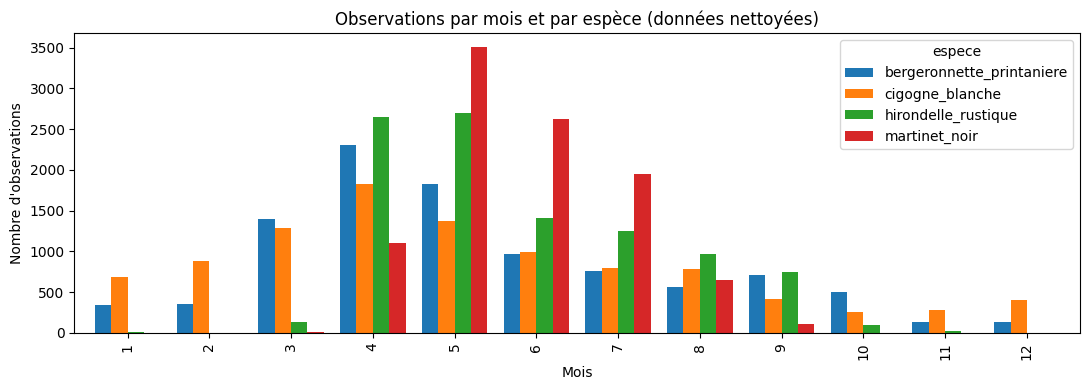

In [7]:
df_propre["mois"] = pd.to_datetime(df_propre["date_observation"]).dt.month
(df_propre.groupby(["mois", "espece"]).size().unstack()
    .plot(kind="bar", figsize=(11, 4), width=0.8))
plt.title("Observations par mois et par espèce (données nettoyées)")
plt.xlabel("Mois")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

## 4. La transformation clé : la grille hebdomadaire présence/absence

Les observations sont éparses (là où quelqu'un a regardé). Pour un modèle de classification, il faut
une grille **complète** : pour chaque semaine × chaque maille géographique × chaque espèce, une ligne
`presence = 1` (au moins une observation) ou `0`.

In [8]:
grille = AggregeurTemporel.creer_grille_hebdomadaire(df_propre)
print("Dimensions de la grille :", grille.shape)
print("\nÉquilibre des classes :")
print(grille["presence"].value_counts())
print(f"\n-> {grille['presence'].mean()*100:.1f} % de présences (fort déséquilibre, à garder en tête pour BC03)")
grille.head()

2026-09-01 17:25:29.167 | INFO     | nettoyage:creer_grille_hebdomadaire:97 - Creation grille hebdomadaire...


2026-09-01 17:25:29.840 | INFO     | nettoyage:creer_grille_hebdomadaire:127 -   Grille creee : 1135680 lignes


2026-09-01 17:25:29.844 | INFO     | nettoyage:creer_grille_hebdomadaire:128 -   Equilibre classes : {0: 1119777, 1: 15903}


Dimensions de la grille : (1135680, 7)

Équilibre des classes :
presence
0    1119777
1      15903
Name: count, dtype: int64

-> 1.4 % de présences (fort déséquilibre, à garder en tête pour BC03)


,annee,semaine,espece,lat_discrete,lon_discrete,nombre_observations,presence
0,2015,1,hirondelle_rustique,51.4,3.9,0.0,0
1,2015,1,hirondelle_rustique,51.4,2.6,0.0,0
2,2015,1,hirondelle_rustique,51.4,3.5,0.0,0
3,2015,1,hirondelle_rustique,51.4,3.8,0.0,0
4,2015,1,hirondelle_rustique,51.4,4.0,0.0,0


## 5. La météo

`traiter_meteo` type les colonnes, trie par date et retire les doublons.

In [9]:
df_meteo = traiter_meteo(REPERTOIRE_DONNEES_BRUTES / "meteo_npdc.csv")
print("Jours de météo :", len(df_meteo))
df_meteo.describe().round(1)

2026-09-01 17:25:29.865 | INFO     | nettoyage:traiter_meteo:160 - Donnees meteo nettoyees : 3653 lignes


Jours de météo : 3653


,date,temperature_max,temperature_min,temperature_moyenne,precipitation_sum,vent_max,humidite_moyenne,pression_moyenne
count,3653,3653.0,3653.0,3653.0,3653.0,3653.0,3653.0,3653.0
mean,2020-01-01 00:00:00,15.3,7.9,11.5,2.0,21.2,78.3,1016.2
min,2015-01-01 00:00:00,-2.9,-7.4,-4.9,0.0,5.5,38.0,975.3
25%,2017-07-02 00:00:00,10.2,3.9,7.1,0.0,15.3,72.0,1010.7
50%,2020-01-01 00:00:00,15.0,8.0,11.2,0.3,19.9,79.0,1017.0
75%,2022-07-02 00:00:00,20.4,12.4,16.3,2.4,26.1,86.0,1022.6
max,2024-12-31 00:00:00,38.2,22.3,29.2,35.4,62.5,99.0,1047.6
std,NaN,6.8,5.5,5.9,3.7,8.2,9.4,9.8


## 6. Écriture des livrables

`executer_nettoyage()` refait tout le pipeline et écrit les fichiers `donnees/traitees/`
consommés par BC02, BC03 et BC05.

In [10]:
executer_nettoyage()

print("Fichiers produits :")
for f in sorted(REPERTOIRE_DONNEES_TRAITEES.glob("*.parquet")):
    print(f"  {f.name:<32} {f.stat().st_size // 1024:>5} Ko")

2026-09-01 17:25:29.877 | INFO     | nettoyage:executer_nettoyage:166 - ============================================================


2026-09-01 17:25:29.877 | INFO     | nettoyage:executer_nettoyage:167 - NETTOYAGE (ETL)


2026-09-01 17:25:29.877 | INFO     | nettoyage:executer_nettoyage:168 - ============================================================


2026-09-01 17:25:29.877 | INFO     | nettoyage:charger_et_nettoyer:32 - Chargement observations : observations_gbif.csv


2026-09-01 17:25:29.901 | INFO     | nettoyage:charger_et_nettoyer:43 -   Observations initiales : 40000


...

2026-09-01 17:25:30.798 | INFO     | nettoyage:executer_nettoyage:205 - Observations nettoyees : 39986


2026-09-01 17:25:30.806 | INFO     | nettoyage:executer_nettoyage:206 - Especes : 4


2026-09-01 17:25:30.806 | INFO     | nettoyage:executer_nettoyage:207 - Plage temporelle : 2019-01-01 00:00:00 a 2024-12-31 00:00:00


2026-09-01 17:25:30.806 | INFO     | nettoyage:executer_nettoyage:211 - Lignes de la grille presence/absence : 1135680


Fichiers produits :
  grille_presence_hebdo.parquet      108 Ko
  meteo_processed.parquet             71 Ko
  observations_nettoyees.parquet     942 Ko


## Récapitulatif

| Fichier | Contenu | Utilisé par |
|---|---|---|
| `donnees/traitees/observations_nettoyees.parquet` | observations validées et dédupliquées | BC02 |
| `donnees/traitees/grille_presence_hebdo.parquet` | grille semaine × maille × espèce, `presence` 0/1 | BC02, BC03 |
| `donnees/traitees/meteo_processed.parquet` | météo journalière nettoyée | BC02, BC03 |

Étapes suivantes : **BC02** (analyse exploratoire) et **BC03** (Machine Learning) partent de ces
fichiers.